# 5. Modelagem — Regressão linear simples

Quinta fase do CRISP-DM. Aqui o objetivo é construir um modelo preditivo enxuto e ver até onde ele chega. Em vez de jogar todas as variáveis dentro de uma regressão múltipla, escolhi um caminho diferente: usar apenas o `delivery_delay_days` como preditor e medir o quanto essa variável sozinha consegue explicar do NPS.

A justificativa vem da EDA. No notebook 04, o modelo agregado com mais de 10 variáveis chegou a R² de 0,56, mas o `delivery_delay_days` sozinho já explicava 0,36 e dominava o ranking de importância. A pergunta natural é: vale a complexidade adicional? Um modelo de uma variável só é mais simples de explicar para gestores, mais fácil de manter, e responde direto à pergunta de negócio que vinha sendo construída desde o notebook 01: "atraso na entrega é a alavanca certa para mexer no NPS?".

A regressão linear simples também tem a vantagem didática de ser exatamente a técnica vista na fase de Estatística (Aula 5), o que mantém o trabalho dentro do escopo do que aprendemos no curso.

## 5.1 Carregamento e setup

Mesmo padrão dos notebooks anteriores. Carrego o dataset processado pela função do módulo `src/nps/data.py`, configuro o tema visual e defino os caminhos de saída para figuras desta fase.

In [1]:
# Bibliotecas principais
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Para o modelo, vou usar duas bibliotecas com proposito diferente:
# - statsmodels: melhor para interpretacao (coeficientes, p-valores, intervalos)
# - sklearn: melhor para o split treino/teste e calculo direto de metricas
import statsmodels.formula.api as smf
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Funcoes do nosso modulo
from nps.data import carregar_dataset_processado

# Reprodutibilidade
SEMENTE_ALEATORIA = 42
np.random.seed(SEMENTE_ALEATORIA)

# Configuracao visual
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["figure.dpi"] = 100

# Caminhos para esse notebook
RAIZ_PROJETO = Path.cwd().parent
PASTA_FIGURAS = RAIZ_PROJETO / "reports" / "figures" / "05_modelagem_regressao"
PASTA_FIGURAS.mkdir(parents=True, exist_ok=True)

# Carrega o dataset processado
dados = carregar_dataset_processado()

print(f"Dataset carregado: {dados.shape[0]:,} linhas x {dados.shape[1]} colunas")
print(f"Target: nps_score (range {dados['nps_score'].min():.1f} a {dados['nps_score'].max():.1f})")
print(f"Preditor escolhido: delivery_delay_days (range {dados['delivery_delay_days'].min()} a {dados['delivery_delay_days'].max()})")

Dataset carregado: 2,500 linhas x 23 colunas
Target: nps_score (range 0.0 a 10.0)
Preditor escolhido: delivery_delay_days (range 0 a 8)


Tudo carregado. A próxima seção define formalmente o modelo e separa o dataset em treino e teste antes de ajustar a regressão.

## 5.2 Definição do modelo e separação treino/teste

O modelo é direto: ajustar uma reta que descreve como o `nps_score` varia conforme o `delivery_delay_days`. Em formato matemático, é uma equação do tipo `nps = a + b * delivery_delay_days`, onde `a` é o ponto onde a reta cruza o eixo y (intercepto) e `b` é a inclinação (quanto o NPS varia para cada dia adicional de atraso). Esses dois números é o que o algoritmo vai estimar a partir dos dados.

### Por que separar treino e teste

Antes de ajustar o modelo, vou separar os 2.500 registros em duas partes. Uma parte (80% das linhas, escolhidas aleatoriamente) vai ser usada para o algoritmo aprender os coeficientes — o conjunto de **treino**. A outra parte (20%) fica de fora desse processo e só vai ser usada depois para medir como o modelo se sai em dados que ele nunca viu — o conjunto de **teste**.

A razão de fazer isso é simples: se eu ajustar o modelo no dataset inteiro e medir performance no mesmo dataset, estou pedindo para o modelo "se lembrar" dos dados, não predizer. Separando antes, o teste mede capacidade real de generalizar para casos novos. É a mesma lógica de quando alguém estuda só pelos exercícios do livro e tira nota boa — o desempenho real só fica claro quando aparece um problema novo na prova.

A semente aleatória fica fixa em 42 para que a divisão seja sempre a mesma cada vez que o notebook é rodado.

In [2]:
# Variavel preditora (X) e target (y)
X = dados[["delivery_delay_days"]]
y = dados["nps_score"]

# Split 80/20 com semente fixa
X_treino, X_teste, y_treino, y_teste = train_test_split(
    X, y,
    test_size=0.2,
    random_state=SEMENTE_ALEATORIA,
)

print(f"Tamanho do conjunto de treino: {len(X_treino):,} linhas")
print(f"Tamanho do conjunto de teste:  {len(X_teste):,} linhas")
print(f"Proporcao teste/total: {len(X_teste) / len(dados):.1%}")
print()

# Verificacao: NPS medio nos dois conjuntos deve ser parecido
print(f"NPS medio no treino: {y_treino.mean():.3f}")
print(f"NPS medio no teste:  {y_teste.mean():.3f}")
print(f"Diferenca: {abs(y_treino.mean() - y_teste.mean()):.3f}")

Tamanho do conjunto de treino: 2,000 linhas
Tamanho do conjunto de teste:  500 linhas
Proporcao teste/total: 20.0%

NPS medio no treino: 4.389
NPS medio no teste:  4.338
Diferenca: 0.051


As médias do NPS nos dois conjuntos ficaram próximas, o que é esperado para um split aleatório bem feito. Se a diferença fosse grande, seria sinal de que a divisão pegou um pedaço enviesado da base. Como está, dá para seguir e ajustar a regressão na próxima seção sabendo que treino e teste representam populações comparáveis.

## 5.3 Ajuste do modelo no conjunto de treino

Com o split feito, agora é a parte central: ajustar a regressão linear no conjunto de treino. Vou usar o `statsmodels` porque ele entrega não só os coeficientes, mas também os intervalos de confiança e p-valores que ajudam a interpretar.

In [3]:
# Reune treino em um DataFrame para usar a sintaxe de formula do statsmodels
dados_treino = pd.concat([X_treino, y_treino], axis=1)

# Ajusta a regressao
modelo = smf.ols("nps_score ~ delivery_delay_days", data=dados_treino).fit()

# Mostra a tabela de coeficientes
print(modelo.summary().tables[1])
print()

# Extrai os dois numeros principais
intercepto = modelo.params["Intercept"]
slope = modelo.params["delivery_delay_days"]
r2_treino = modelo.rsquared

print(f"Equacao do modelo:")
print(f"  nps_predito = {intercepto:.2f} + ({slope:.2f}) x delivery_delay_days")
print()
print(f"R-quadrado no treino: {r2_treino:.3f}")

                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
Intercept               6.6276      0.083     80.315      0.000       6.466       6.789
delivery_delay_days    -1.0244      0.032    -32.489      0.000      -1.086      -0.963

Equacao do modelo:
  nps_predito = 6.63 + (-1.02) x delivery_delay_days

R-quadrado no treino: 0.346


**Como ler a tabela:** as duas linhas que aparecem são os coeficientes da reta. `Intercept` é o ponto onde a reta cruza o eixo y, ou seja, a previsão de NPS para um cliente com zero dias de atraso. `delivery_delay_days` é a inclinação da reta — quanto o NPS muda para cada dia adicional de atraso. Os números entre colchetes (`[0.025` e `0.975]`) são o intervalo de confiança a 95% para cada coeficiente; o `P>|t|` é o p-valor que testa se o coeficiente é estatisticamente diferente de zero.

### Interpretação prática

A equação ajustada é, em números arredondados:

> nps_predito = 6,63 - 1,02 × delivery_delay_days

Em linguagem direta, o modelo está dizendo duas coisas. Primeiro, **um cliente cuja entrega chegou no prazo (zero dias de atraso) tem previsão de NPS em torno de 6,6** — bem próximo da fronteira entre detrator e neutro, mas ainda do lado detrator pela régua canônica. Segundo, **cada dia de atraso reduz a previsão de NPS em aproximadamente 1,02 ponto**.

Para sentir isso na prática, dá para projetar alguns cenários: cliente com 2 dias de atraso (mediana do dataset) cai para NPS ≈ 4,6; com 4 dias vai para ≈ 2,5; com 6 dias chega perto de 0,5. Os dois coeficientes têm p-valor essencialmente zero, ou seja, não há dúvida estatística sobre o efeito.

O R² no treino é 0,346, levemente abaixo do que o modelo agregado da seção 4.10 atingia (0,56), mas com uma vantagem importante: a explicação do que o modelo faz cabe em uma frase. A próxima seção mede como ele se sai no conjunto de teste, que é o que de fato importa para uso prático.

## 5.4 Avaliação no conjunto de teste

Agora vem o teste de fato: usar o modelo para prever o NPS dos 500 clientes do conjunto de teste e medir a diferença entre o que ele previu e o que aconteceu de verdade. Como o conjunto de teste ficou de fora do ajuste, esses números mostram o desempenho real do modelo em dados novos.

Vou olhar três métricas, todas em pontos de NPS na mesma escala da target:

- **R²:** fração da variabilidade do NPS que o modelo conseguiu explicar (vai de 0 a 1)
- **MAE (erro absoluto médio):** em média, quantos pontos de NPS o modelo erra para cima ou para baixo
- **RMSE (raiz do erro quadrado médio):** parecido com o MAE, mas penaliza mais os erros grandes (porque eleva ao quadrado antes de somar)

Para servir de referência, vou comparar o modelo com um **baseline ingênuo** que sempre prevê a média do treino, sem usar nenhuma variável. Se o nosso modelo não vencer essa linha de base, é porque a variável `delivery_delay_days` não está agregando informação útil.

In [4]:
# Predicoes do modelo no treino e no teste
dados_teste = pd.concat([X_teste, y_teste], axis=1)

y_pred_treino = modelo.predict(dados_treino)
y_pred_teste  = modelo.predict(dados_teste)

# Metricas
def metricas(y_real, y_pred):
    return {
        "R2":   r2_score(y_real, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_real, y_pred)),
        "MAE":  mean_absolute_error(y_real, y_pred),
    }

m_treino = metricas(y_treino, y_pred_treino)
m_teste  = metricas(y_teste, y_pred_teste)

# Baseline ingenuo: prever sempre a media do treino
media_treino = y_treino.mean()
y_pred_baseline = np.full(len(y_teste), media_treino)
m_baseline = metricas(y_teste, y_pred_baseline)

# Tabela comparativa
tabela_metricas = pd.DataFrame({
    "Treino (modelo)":   m_treino,
    "Teste (modelo)":    m_teste,
    "Teste (baseline)":  m_baseline,
}).round(4)
print("Comparacao de desempenho:")
print(tabela_metricas.to_string())
print()
print(f"Media usada pelo baseline: {media_treino:.3f}")
print(f"Reducao do MAE em relacao ao baseline (no teste): {(1 - m_teste['MAE'] / m_baseline['MAE']):.1%}")

Comparacao de desempenho:
      Treino (modelo)  Teste (modelo)  Teste (baseline)
R2             0.3457          0.4004           -0.0004
RMSE           2.0292          1.9465            2.5142
MAE            1.6463          1.5774            2.0688

Media usada pelo baseline: 4.389
Reducao do MAE em relacao ao baseline (no teste): 23.8%


**Como interpretar a tabela:** as três colunas são "modelo no treino", "modelo no teste" e "baseline no teste". A primeira mostra o desempenho do modelo nos dados que ele aprendeu; a segunda mostra como ele generaliza; a terceira é o piso de comparação (qualquer modelo razoável precisa ser melhor do que isso).

Em geral, o modelo no treino tende a ser melhor que no teste, porque os dados de treino são exatamente os que o modelo "memorizou". Quando treino e teste ficam parecidos, é sinal de que o modelo generalizou bem. Se a diferença for grande, com o treino muito melhor que o teste, é sinal de **decoreba** (em ML chamam de overfitting): o modelo aprendeu peculiaridades dos dados de treino que não se aplicam fora dali.

### Leitura dos números

Três coisas saltam.

A primeira é que **o teste ficou levemente melhor que o treino** (R² 0,40 vs 0,35; RMSE 1,95 vs 2,03). Esse padrão é incomum mas não é problema: significa que o conjunto de teste, por sorte da divisão aleatória, ficou um pouco "mais fácil" — clientes com distribuição de atrasos mais próxima daquilo que o modelo previu bem. O importante é que os dois números são parecidos, o que descarta o cenário de decoreba.

A segunda é que **o modelo está bem acima do baseline ingênuo**. O baseline tem R² praticamente zero (porque por definição não consegue explicar variação se sempre chuta a média), MAE de 2,07 e RMSE de 2,51. O modelo simples reduz o MAE para 1,58 — uma queda de aproximadamente 24% no erro médio. Em pontos de NPS, isso é a diferença entre errar 2 pontos e errar 1,5 ponto, o que para uma escala de 0 a 10 é um ganho concreto.

A terceira é que, mesmo com esse ganho, **o erro absoluto ainda é de aproximadamente 1,6 ponto de NPS**. Em uma escala de 0 a 10, isso significa que o modelo geralmente acerta a região, mas pode errar a categoria canônica (detrator/neutro/promotor) em casos próximos das fronteiras. É uma limitação importante para registrar quando for usar o modelo na prática: ele serve melhor para indicar tendência do que para chutar a nota exata de cada cliente.

## 5.5 Visualização do ajuste

Os números da seção anterior mostram que o modelo funciona, mas é mais informativo ver visualmente o que ele está fazendo. Vou plotar os pontos do conjunto de teste com a reta da regressão sobreposta, colorindo cada cliente pela categoria de NPS observada (detrator, neutro ou promotor) para ver se a reta atravessa as três regiões da forma esperada.

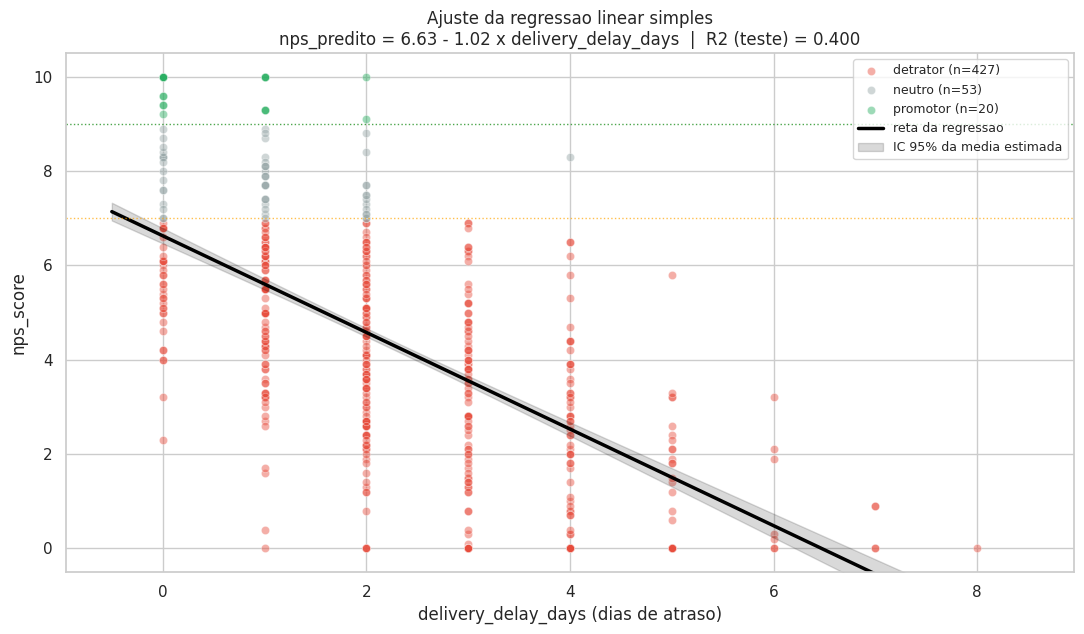

In [5]:
# Cores semanticas que vamos manter consistentes em todo o trabalho
cores_buckets = {"detrator": "#e74c3c", "neutro": "#95a5a6", "promotor": "#27ae60"}

# Predicoes da regressao em uma grade fina, para tracar a reta suave
grade_atraso = np.linspace(dados["delivery_delay_days"].min() - 0.5,
                           dados["delivery_delay_days"].max() + 0.5,
                           100)
df_grade = pd.DataFrame({"delivery_delay_days": grade_atraso})

# get_prediction retorna intervalo de confianca para a media (mean_ci) e para uma observacao individual
predicao_grade = modelo.get_prediction(df_grade)
resumo_predicao = predicao_grade.summary_frame(alpha=0.05)

# Junta dataset de teste com a categoria do nps observado para colorir
dados_teste_viz = dados.loc[X_teste.index].copy()

fig, eixo = plt.subplots(figsize=(11, 6.5))

# Pontos do teste, coloridos por categoria
for cat in ["detrator", "neutro", "promotor"]:
    pontos = dados_teste_viz[dados_teste_viz["categoria_nps"] == cat]
    eixo.scatter(
        pontos["delivery_delay_days"], pontos["nps_score"],
        alpha=0.45, s=35, color=cores_buckets[cat], edgecolor="white", linewidth=0.5,
        label=f"{cat} (n={len(pontos)})",
    )

# Reta da regressao
eixo.plot(grade_atraso, resumo_predicao["mean"], color="black", linewidth=2.5, label="reta da regressao")

# Faixa de IC 95% para a media estimada
eixo.fill_between(
    grade_atraso, resumo_predicao["mean_ci_lower"], resumo_predicao["mean_ci_upper"],
    color="black", alpha=0.15, label="IC 95% da media estimada",
)

# Linhas tracejadas marcando os cortes canonicos do NPS
eixo.axhline(7, color="orange", linestyle=":", linewidth=1, alpha=0.7)
eixo.axhline(9, color="green",  linestyle=":", linewidth=1, alpha=0.7)

eixo.set_xlabel("delivery_delay_days (dias de atraso)")
eixo.set_ylabel("nps_score")
eixo.set_title(f"Ajuste da regressao linear simples\nnps_predito = {intercepto:.2f} - {abs(slope):.2f} x delivery_delay_days  |  R2 (teste) = {m_teste['R2']:.3f}")
eixo.legend(loc="upper right", fontsize=9)
eixo.set_ylim(-0.5, 10.5)
fig.tight_layout()
fig.savefig(PASTA_FIGURAS / "5_5_ajuste_regressao.png", dpi=120, bbox_inches="tight")
plt.show()

![Ajuste da regressão linear simples no conjunto de teste](../reports/figures/05_modelagem_regressao/5_5_ajuste_regressao.png)

**Como ler este gráfico:** o eixo X mostra os dias de atraso na entrega; o eixo Y mostra o `nps_score` observado. Cada ponto é um cliente do conjunto de teste, **colorido pela categoria de NPS observada** (vermelho = detrator, cinza = neutro, verde = promotor).

A **linha preta sólida** é a reta da regressão ajustada no conjunto de treino, projetada sobre toda a faixa de atrasos. A **faixa cinza ao redor da reta** é o intervalo de confiança a 95% da média estimada — uma região onde o modelo tem segurança razoável de que a média do NPS naquela faixa de atraso cai. As **linhas tracejadas horizontais** em 7 (laranja) e 9 (verde) marcam os cortes canônicos detrator/neutro/promotor, para dar referência visual.

**O que procurar:** se o modelo estiver capturando bem a relação, a reta deve atravessar a nuvem de pontos por dentro, com aproximadamente metade dos pontos acima e metade abaixo em cada faixa de atraso. As cores ajudam a ver onde o modelo erra mais — se houver muitos pontos verdes (promotores reais) na região onde a reta prevê NPS baixo, é sinal de que o modelo está subestimando esses clientes; o oposto vale para os vermelhos.

A leitura visual confirma vários pontos da seção anterior.

A reta atravessa a nuvem de pontos com inclinação clara para baixo: começa perto de NPS 6,6 quando o atraso é zero e vai descendo cerca de 1 ponto por dia, até cruzar a região dos detratores em torno de 4-5 dias de atraso. A faixa cinza do IC 95% é estreita, o que dá segurança de que a média estimada por faixa de atraso é confiável.

O ponto importante é a **dispersão vertical em cada coluna de atraso**. Mesmo entre clientes que tiveram exatamente 2 dias de atraso, há uma variedade enorme de notas: alguns são detratores (pontos vermelhos lá embaixo), alguns são neutros (cinzas), e até alguns são promotores (verdes mais raros lá em cima). O modelo prevê a **média** dessa coluna, mas nenhum cliente individual cai exatamente na média. Essa é a fonte do erro absoluto de 1,58 pontos que vimos na seção anterior.

Outra observação útil é que **o modelo tende a errar na ponta dos atrasos**. Para clientes com 8 dias de atraso (extremo direito), a reta prevê NPS abaixo de zero, o que é matematicamente previsto pela equação mas operacionalmente sem sentido (NPS não vai abaixo de 0). Isso é uma limitação típica de regressão linear quando aplicada fora do intervalo central dos dados, e é mais um motivo para o modelo ser usado como **indicação de tendência**, não como previsão pontual literal.

A próxima seção olha exatamente para onde o modelo erra mais, examinando os resíduos.